In [6]:
from utils.model_builder import build_model
import utils.constants as constants

import time
from custom_classes.custom_estimator_qnn import CustomEstimatorQNN

from torch.nn import BCEWithLogitsLoss, Sigmoid

from qiskit_machine_learning.connectors import TorchConnector

import time

import torch
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
from qiskit_algorithms.utils import algorithm_globals


# from qiskit.circuit.library import RealAmplitudes

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

from qiskit.primitives import Estimator
from qiskit_algorithms.gradients import ReverseEstimatorGradient

from matplotlib import pyplot as plt
# from qiskit.primitives import Sampler

# import constants
import utils.ansatz_builder as ansatz_builder

from dropout.main import DropoutType as DT
import dropout.data.dictionary.DropoutData as DD

import utils.tasks_manager as tasks_manager
import utils.constants as constants
import os
import time

import tqdm

from utils.train_and_test import train, grid_evaluator

import matplotlib.pyplot as plt
import numpy as np



In [7]:
# ------------------------------------------------ DROPOUT-RELATED STUFF ------------------------------------------------------|
                                                                                                                              #|
dropout_code = "C"                                                                                                            #|
                                                                                                                              #|
circ_data_dict = {'num_qubit' : 5, 'reps' : 10}                                                                               #|
                                                                                                                              #|
softness = 0.1                                                                                                                #|
p_drop = 0.5                                                                                                                  #|
                                                                                                                              #|
partial_dropout_data = DD.DropoutData(dropout_type = DT.DropoutType.CANONICAL, softness = softness, prob = p_drop)            #|
model, feature_map, single_layer = build_model(constants.ModelType.ROTATIONAL_REGRESSOR, circ_data_dict, partial_dropout_data)#|
                                                                                                                              #|
                                                                                                                              #|
#-------------------------------------------------------------------------------------------------------------------------------

In [8]:

plt.rc('text', usetex=False)

seed = 1
np.random.seed(seed)
torch.manual_seed(seed)


task = constants.Tasks.REGRESSION_SINE
task_name = task.value
X_train, y_train, X_test, y_test, X_, y_ = tasks_manager.generate_task(task,
                                                               num_samples_train = 15,
                                                               num_samples_test = 5,
                                                               show = False,
                                                               seed = seed)
fX_train = tasks_manager.prepare_features(X_train, task)
fX_test = tasks_manager.prepare_features(X_test, task)
fX_ = tasks_manager.prepare_features(X_, task)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
fX_tensor = torch.from_numpy(fX_).float().to(device)

Task regression_sine saved at data/task_regression_sine


In [9]:
model.activate_dropout()
with torch.no_grad():
    y_predicted = model(fX_tensor).cpu()  # Using the model's call method for inference

/tmp/ipykernel_2274919/161194541.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("example_model.pt", map_location=torch.device('cpu')))


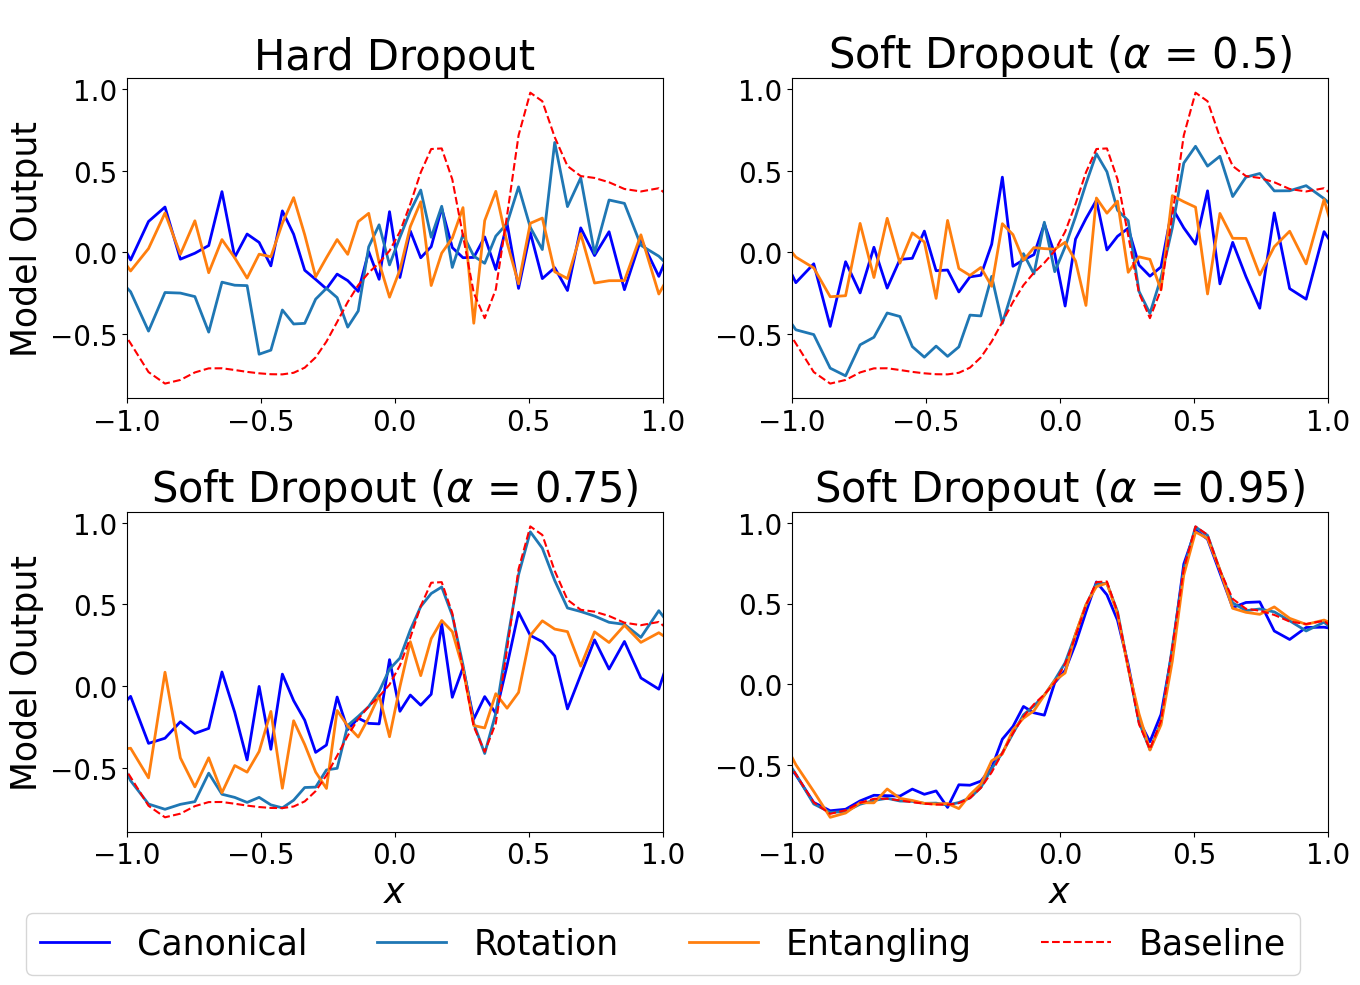

In [10]:
import numpy as np
import matplotlib.pyplot as plt

p_drop = 0.05
softnesses = [0, 0.5, 0.75, 0.95]

model.load_state_dict(torch.load("example_model.pt", map_location=torch.device('cpu')))
weights = model.qnn.state_dict()

# Assuming fX_tensor is your input tensor
# Extract x-values from fX_tensor
x_values = fX_tensor.cpu().numpy()
# If x_values is multidimensional, select the appropriate dimension
# For example, if x_values.shape is (N, D), and x is the first feature:
x_values = x_values[:, 0]


# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Increase font sizes globally
plt.rcParams.update({'font.size': 20})

for idx, (softness, ax) in enumerate(zip(softnesses, axes.flatten())):
    y_predictions = {}
    # Define the dropouts for this softness
    dropouts = {
            'Canonical': DD.DropoutData(dropout_type = DT.DropoutType.CANONICAL, softness = softness, prob = p_drop),   
            'Rotation': DD.DropoutData(dropout_type = DT.DropoutType.ROTATION, softness = softness, prob = p_drop),
            'Entangling': DD.DropoutData(dropout_type = DT.DropoutType.ENTANGLING, softness = softness, prob = p_drop),
            'Baseline': None
    }
    for name, dropout in dropouts.items():
        new_dropout = dropout
        # Build the model with the given dropout
        if name != 'Baseline':
            model, feature_map, single_layer = build_model(constants.ModelType.ROTATIONAL_REGRESSOR, circ_data_dict, new_dropout)
            model.qnn.load_state_dict(weights)
            model.to(device)
        
        # Activate or deactivate dropout based on the dropout type
        if dropout is not None:
            model.activate_dropout()
        else:
            model.deactivate_dropout()
        
        # Perform prediction
        with torch.no_grad():
            y_predicted = model(fX_tensor).cpu()
        y_predictions[name] = y_predicted.numpy()
    
    # Plot the predictions
    for name, y_pred in y_predictions.items():
        if name == 'Baseline':
            ax.plot(x_values, y_pred, label=name, linestyle='--', color='red', linewidth=1.5)
        else:
            #ax.plot(x_values, y_pred, label=name, marker='o', markersize=3, linewidth=1)
            # if name == 'Canonical' use dark blue as color
            if name == 'Canonical':
                ax.plot(x_values, y_pred, label=name, color='blue', linewidth=2)
            else:
                ax.plot(x_values, y_pred, label=name, linewidth=2)

            #ax.plot(x_values, y_pred, label=name, linewidth=2)
    if idx >= 2:  # idx == 2 or idx == 3
        ax.set_xlabel('$x$', fontsize=25)
    else:
        ax.set_xlabel('')
    if idx == 0 or idx == 2:
        ax.set_ylabel('Model Output', fontsize=25)
    else:
        ax.set_ylabel('')
    # Set title
    if softness == 0:
        title = 'Hard Dropout'
    else:
        title = f'Soft Dropout ($\\alpha$ = {softness})'
    ax.set_title(title, fontsize=30)
    ax.set_xlim([-1, 1])
    ax.tick_params(axis='both', which='major', labelsize=20)
    # Adjust x-t
    #save image
plt.suptitle(" ")
plt.tight_layout(rect=[0, 0.05, 1, 1.05])
axes[-1][0].legend(
    fontsize=25,
    loc='upper center',
    bbox_to_anchor=(1.0, -0.2),
    ncol=4,
)
#plt.savefig(f"selected_images/evaluate_final_colormod.pdf")
plt.show()
